In [13]:
!pip install pandas numpy==2.0.0 scikit-learn==1.7.0 seaborn

In [25]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit
from sklearn.utils.multiclass import unique_labels


In [15]:
# I. Préparation des données
# Paramètres
DATA_PATH = 'vessel_sampled.csv'
PREPROCESSOR_PATH = 'preprocessor_vessel_type.pkl'
MODEL_PATH = 'rf_vessel_type_classifier.pkl'

FEATURES = [
    'Status','Length', 'Width', 'Draft', 'Cargo', 'Heading'
]
TARGET = 'VesselType'
CATEGORICAL = ['Status', 'Cargo']
NUMERICAL = ['Length', 'Width', 'Draft', 'Heading']

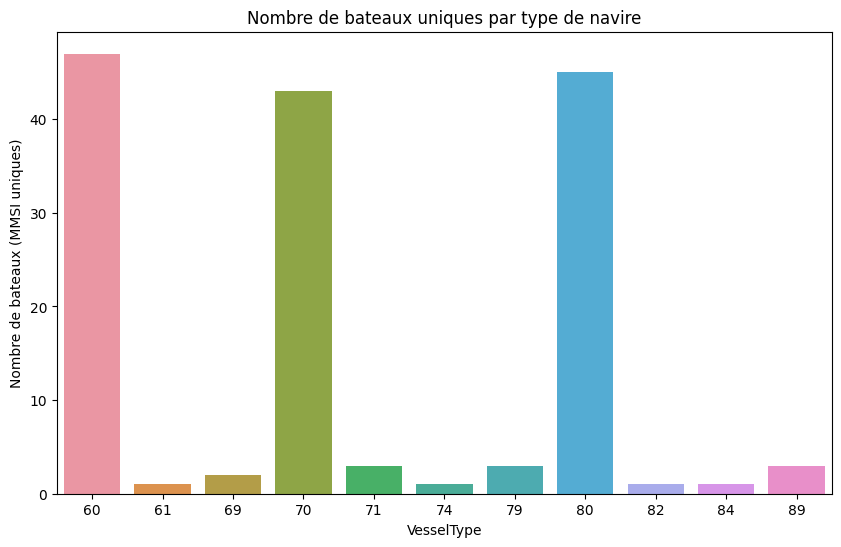

In [16]:
# On ouvre le csv
df = pd.read_csv(DATA_PATH)
# On compte le nombre de chaque VesselType
vesseltype_counts = df.groupby('VesselType')['MMSI'].nunique().reset_index(name='Nombre de bateaux')
# On affiche le nombre de chaque VesselType avec un graphe
plt.figure(figsize=(10,6))
sns.barplot(data=vesseltype_counts, x='VesselType', y='Nombre de bateaux')
plt.title('Nombre de bateaux uniques par type de navire')
plt.xlabel('VesselType')
plt.ylabel('Nombre de bateaux (MMSI uniques)')
plt.show()

# On retire les VesselType sous representé(<5) car non exploitable correctement
vesseltype_mmsi_counts = df.groupby('VesselType')['MMSI'].nunique()
rare_types = vesseltype_mmsi_counts[vesseltype_mmsi_counts < 5].index
df = df[~df['VesselType'].isin(rare_types)]

In [17]:
# Séparation X/y
X = df[FEATURES]
y = df[TARGET]

In [18]:
# Pipeline de prétraitement
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
    ('num', StandardScaler(), NUMERICAL),
])

# Fit et transform
X_processed = preprocessor.fit_transform(X)
print(f"Shape après prétraitement : {X_processed.shape}")

Shape après prétraitement : (13500, 34)


In [19]:
# Sauvegarde du préprocesseur
with open(PREPROCESSOR_PATH, 'wb') as f:
    pickle.dump(preprocessor, f)
print(f"Préprocesseur sauvegardé dans {PREPROCESSOR_PATH}")

Préprocesseur sauvegardé dans preprocessor_vessel_type.pkl


In [20]:
# Séparation train/test

# Split test (20%), train (80%)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['MMSI']))

df_train = df.iloc[train_idx]
df_test = df.iloc[test_idx]

print('Train:', df_train['MMSI'].nunique())
print('Test:', df_test['MMSI'].nunique())

# Séparation X/y
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

# Prétraitement sur les splits
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

Train: 108
Test: 27


In [21]:
# III. Métriques pour la classification
# Définir la grille d’hyperparamètres à tester
param_grid = {
    'n_estimators': [1,5,25],
    'max_depth': [None,2,10],
    'min_samples_split': [2,5]
}

# Instancier le modèle de base
rf = RandomForestClassifier(random_state=42)

# GridSearchCV avec validation croisée 5-fold
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)
grid_search.fit(X_train_processed, y_train)

print("Meilleurs hyperparamètres :", grid_search.best_params_)
print("Meilleur score F1 (macro) :", grid_search.best_score_)

# Évaluer le meilleur modèle sur le test set
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_train_processed)
print(classification_report(y_train, y_pred_best, zero_division=0))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Meilleurs hyperparamètres : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 5}
Meilleur score F1 (macro) : 1.0
              precision    recall  f1-score   support

          60       1.00      1.00      1.00      3900
          70       1.00      1.00      1.00      3600
          80       1.00      1.00      1.00      3300

    accuracy                           1.00     10800
   macro avg       1.00      1.00      1.00     10800
weighted avg       1.00      1.00      1.00     10800



In [22]:
# II. Apprentissage supervisé pour la classification
rf = RandomForestClassifier(n_estimators=5, random_state=42, min_samples_split=2, max_depth=None)
rf.fit(X_train_processed, y_train)
y_pred_rf = rf.predict(X_test_processed)

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(rf, f)
print('Modèle Random Forest sauvegardé.')

Modèle Random Forest sauvegardé.


Accuracy: 0.9577777777777777
Precision (macro): 0.9533169533169533
Recall (macro): 0.9683333333333334
F1-score (macro): 0.9582780025680409
              precision    recall  f1-score   support

          60       1.00      1.00      1.00       800
          70       0.86      1.00      0.92       700
          80       1.00      0.91      0.95      1200

    accuracy                           0.96      2700
   macro avg       0.95      0.97      0.96      2700
weighted avg       0.96      0.96      0.96      2700



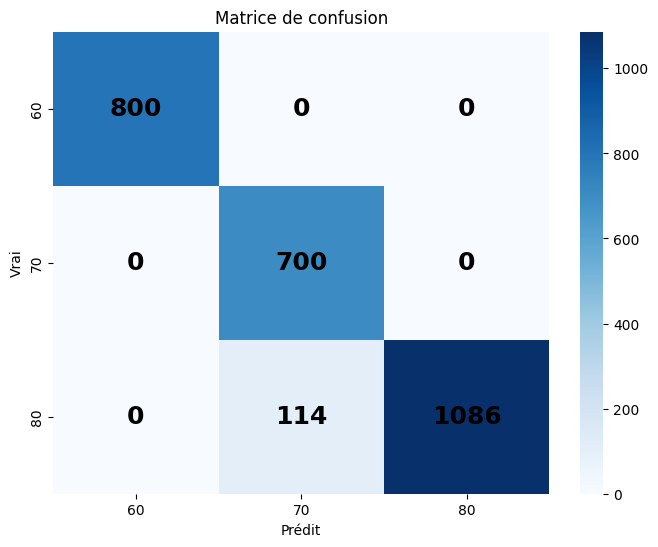

In [35]:
# Prédictions avec Random Forest
with open(MODEL_PATH, 'rb') as f:
    rf = pickle.load(f)
y_pred = rf.predict(X_test_processed)

# Métriques principales
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average='macro', zero_division=0))
print("Recall (macro):", recall_score(y_test, y_pred, average='macro', zero_division=0))
print("F1-score (macro):", f1_score(y_test, y_pred, average='macro'))

# Rapport détaillé
print(classification_report(y_test, y_pred, zero_division=0))

# Matrice de confusion

labels = unique_labels(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(8,6))
ax = sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=labels, yticklabels=labels)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j+0.5, i+0.5, str(cm[i, j]),
                ha='center', va='center', color='black', fontsize=18, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion')
plt.show()

In [ ]:
!python script_predict_vesseltype.py --Status 15 --Length 100 --Width 12 --Draft 6.8 --Cargo 70 --Heading 249

Type de navire prédit : 70
